# Titanic Dataset Feature Engineering and Selection

## Objective
The objective of this project is to prepare the Titanic dataset for machine learning by performing data cleaning, feature engineering, feature transformations, and feature selection. These steps improve the quality of the dataset and help identify the most important variables for predicting passenger survival.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()


## Loading the dataset
The training dataset contains the `Survived` column, which is the target variable. The test dataset is mainly for optional prediction work and does not include the target.

In [4]:
train.shape
train.columns
train.info()
train.describe(include='all')
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
train.isnull().sum().sort_values(ascending=False)
train["AgeMissing"] = train["Age"].isnull().astype(int)
train["Age"] = train["Age"].fillna(train["Age"].median())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train["Fare"] = train["Fare"].fillna(train["Fare"].median())
train["CabinMissing"] = train["Cabin"].isnull().astype(int)

### Missing Value Handling
- `Age` was imputed using the median because it is a numerical variable and median is robust to outliers.
- `Embarked` was imputed using the mode because it is categorical and has few missing values.
- `Cabin` has many missing values, so a missing indicator was created and deck information was extracted later rather than filling the raw values directly.

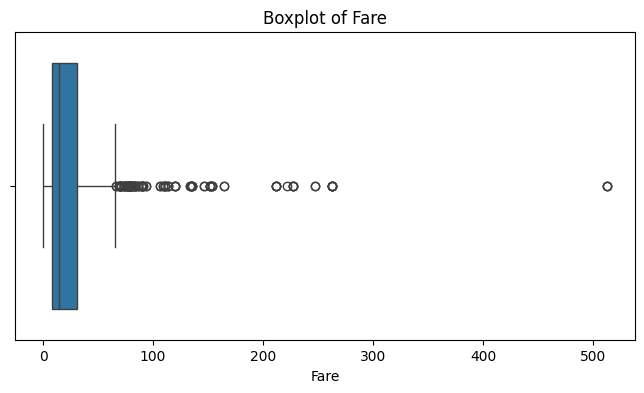

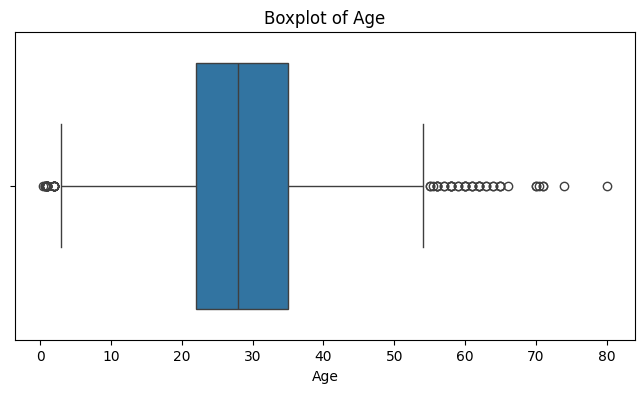

In [6]:
plt.figure(figsize=(8,4))
sns.boxplot(x=train["Fare"])
plt.title("Boxplot of Fare")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=train["Age"])
plt.title("Boxplot of Age")
plt.show()

In [7]:
Q1 = train["Fare"].quantile(0.25)
Q3 = train["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

In [8]:
train["Fare"] = np.where(train["Fare"] > upper_bound, upper_bound, train["Fare"])

### Outlier Handling
Outliers were examined in `Fare` and `Age` using boxplots. `Fare` showed strong skewness and extreme high values, so outlier capping was applied using the IQR method. This helps reduce the influence of extreme ticket prices without removing valid passengers from the dataset.

In [14]:
train["Sex"] = train["Sex"].str.strip().str.lower()
train["Embarked"] = train["Embarked"].astype(str).str.strip().str.upper()
train["Sex"].unique()
train["Embarked"].unique()

train.duplicated().sum()
train = train.drop_duplicates()

### Data Consistency
Text-based categorical variables were standardized to avoid hidden inconsistencies caused by case or spacing differences. Duplicate rows were also checked and removed where necessary.

In [15]:
train.to_csv("../data/train_cleaned.csv", index=False)

The cleaned dataset was saved as `train_cleaned.csv` for use in later feature engineering and modeling steps.

In [16]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
train[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [17]:
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
train[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [18]:
train["Title"] = train["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
train["Title"] = train["Title"].str.strip()
train["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [19]:
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
train["Title"] = train["Title"].replace(rare_titles, "Rare")
train["Title"] = train["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

In [20]:
train["Deck"] = train["Cabin"].apply(lambda x: x[0] if pd.notnull(x) else "Unknown")
train["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [21]:
def age_group(age):
    if age < 13:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

train["AgeGroup"] = train["Age"].apply(age_group)
train["AgeGroup"].value_counts()

AgeGroup
Adult     701
Teen       95
Child      69
Senior     26
Name: count, dtype: int64

In [22]:
train["FarePerPerson"] = train["Fare"] / train["FamilySize"]
train[["Fare", "FamilySize", "FarePerPerson"]].head()

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.6250
1,65.6344,2,32.8172
2,7.9250,1,7.9250
3,53.1000,2,26.5500
4,8.0500,1,8.0500


In [23]:
train_encoded = pd.get_dummies(
    train,
    columns=["Sex", "Embarked", "Title", "Deck", "AgeGroup"],
    drop_first=True
)

### Categorical Encoding
Nominal features such as `Sex`, `Embarked`, `Title`, `Deck`, and `AgeGroup` were one-hot encoded because their categories do not have a natural numeric order. `Pclass` was retained as an ordinal numeric feature because its values represent ordered passenger classes.

In [24]:
train_encoded["Pclass_Fare"] = train_encoded["Pclass"] * train_encoded["Fare"]

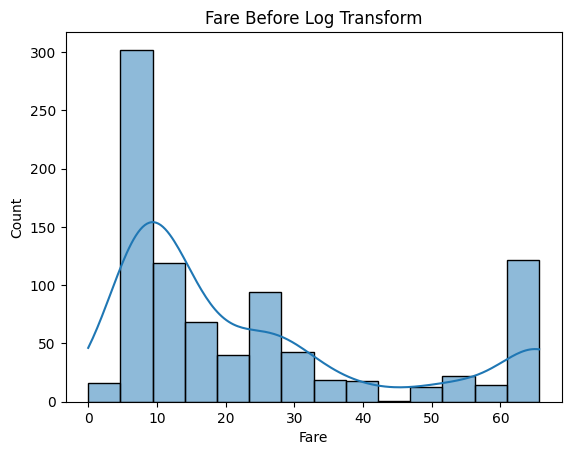

In [25]:
sns.histplot(train["Fare"], kde=True)
plt.title("Fare Before Log Transform")
plt.show()

In [26]:
train_encoded["FareLog"] = np.log1p(train_encoded["Fare"])
train_encoded["AgeLog"] = np.log1p(train_encoded["Age"])

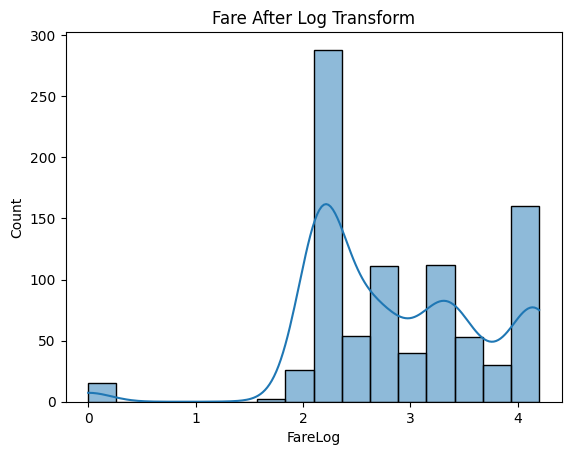

In [27]:
sns.histplot(train_encoded["FareLog"], kde=True)
plt.title("Fare After Log Transform")
plt.show()

In [28]:
scaler = StandardScaler()
scale_cols = ["Age", "Fare", "FamilySize", "FarePerPerson", "FareLog", "AgeLog"]
train_encoded[scale_cols] = scaler.fit_transform(train_encoded[scale_cols])

### Feature Transformations
`Fare` was highly right-skewed, so a log transformation was applied to reduce skewness and compress extreme values. Numeric features were also standardized to make them suitable for models that depend on feature scale, such as KNN or logistic regression.